## Площадь под графиком и управление порогом

### Классная работа

In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [27]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)  # 1000 обьектов, 50 на 50, 2 класса

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [31]:
model = LogisticRegression().fit(X_train, y_train)

In [33]:
y_pred_proba = model.predict_proba(X_test)
print(y_pred_proba)
#display(y_pred_proba)

[[4.02958497e-03 9.95970415e-01]
 [2.00643855e-03 9.97993561e-01]
 [9.94696564e-01 5.30343592e-03]
 [8.47909962e-01 1.52090038e-01]
 [1.66614096e-03 9.98333859e-01]
 [4.99240075e-01 5.00759925e-01]
 [9.80208762e-01 1.97912375e-02]
 [9.76507391e-01 2.34926092e-02]
 [1.79866697e-02 9.82013330e-01]
 [2.93132539e-01 7.06867461e-01]
 [9.95836132e-01 4.16386810e-03]
 [2.53456369e-01 7.46543631e-01]
 [9.92314475e-01 7.68552501e-03]
 [3.80237693e-02 9.61976231e-01]
 [6.47256719e-02 9.35274328e-01]
 [1.91873737e-01 8.08126263e-01]
 [8.55142720e-01 1.44857280e-01]
 [4.34150814e-02 9.56584919e-01]
 [8.43060465e-01 1.56939535e-01]
 [5.51009943e-02 9.44899006e-01]
 [1.32996996e-01 8.67003004e-01]
 [5.89343759e-01 4.10656241e-01]
 [9.79492824e-01 2.05071761e-02]
 [3.32717535e-01 6.67282465e-01]
 [9.95735139e-01 4.26486101e-03]
 [4.32960210e-02 9.56703979e-01]
 [3.06747941e-01 6.93252059e-01]
 [5.58496147e-03 9.94415039e-01]
 [9.75085912e-01 2.49140883e-02]
 [4.49565464e-01 5.50434536e-01]
 [2.079905

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])  # индекс 1, fpr возращает метрики, порог от 0 до 1

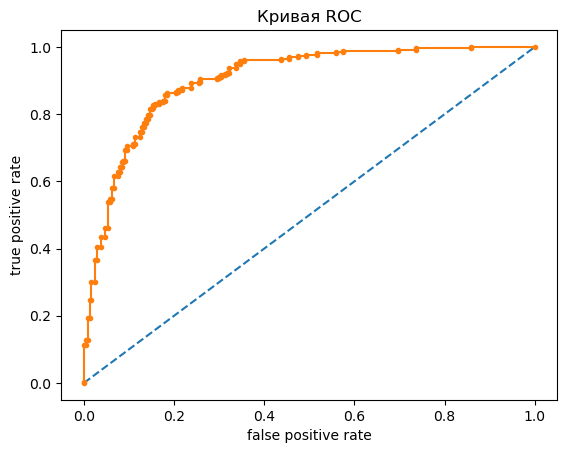

In [37]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('Кривая ROC')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.show()

подобрать пороговое значение (точку) при котором false positive rate минимальный, а true positive rate максимальный

In [40]:
roc_auc_score(y_test, y_pred_proba[:, 1])  # площадь

0.9027724358974359

In [42]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

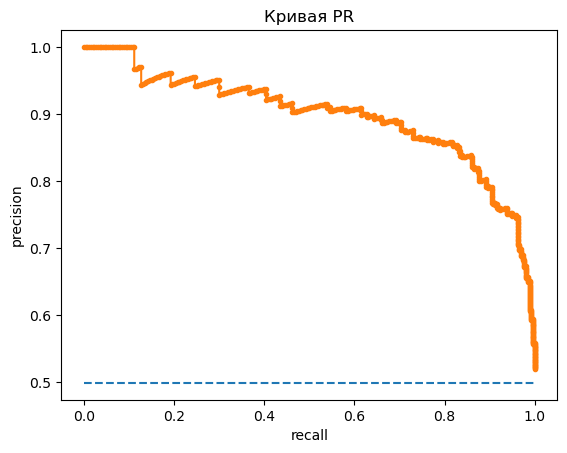

In [44]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')

plt.plot(recall, precision, marker='.')
plt.title('Кривая PR')
plt.xlabel('recall')
plt.ylabel('precision')

plt.show()

recall и precision когда равны 1 получается идеальная кривая PR, синяя травиальная модель 0,5 (посчитали среднюю)

In [47]:
auc(recall, precision)

0.897662372903334

In [49]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [51]:
from sklearn.neighbors import KNeighborsClassifier

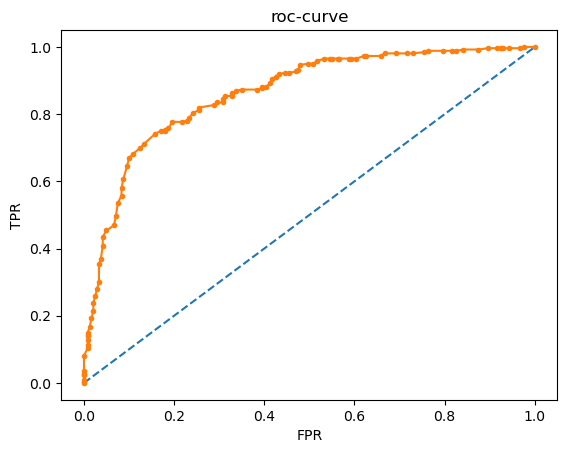

In [53]:
model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])
plt.title('roc-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [54]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.8630608974358974

Дизбаланс классов

In [58]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=490, Class1=10
Тестовая: Class0=495, Class1=5


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=492, Class1=8
Тестовая: Class0=493, Class1=7


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [66]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

In [68]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       0.00      0.00      0.00         8

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.98      0.98       500



C:\Users\Home\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


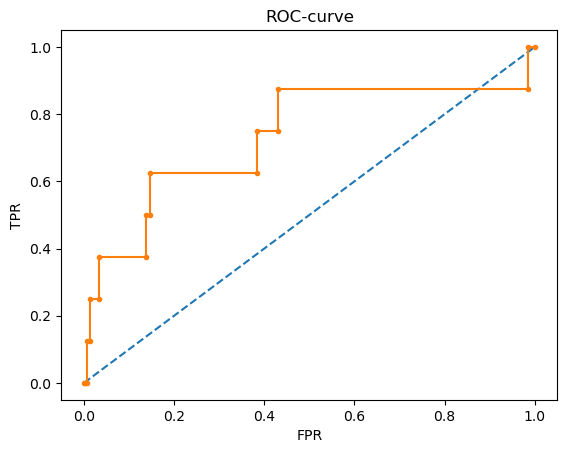

In [70]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

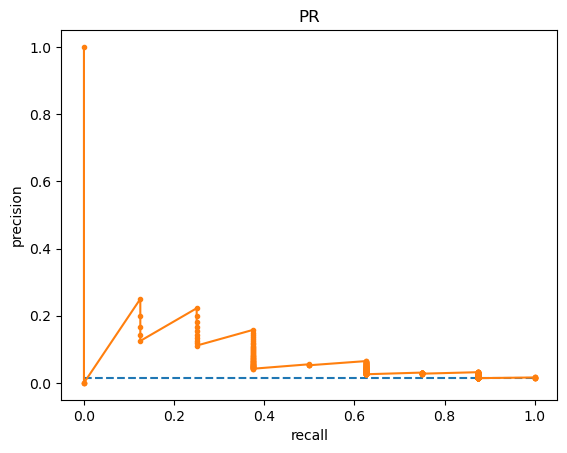

In [72]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

Выбор значения порога по кривым

In [75]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

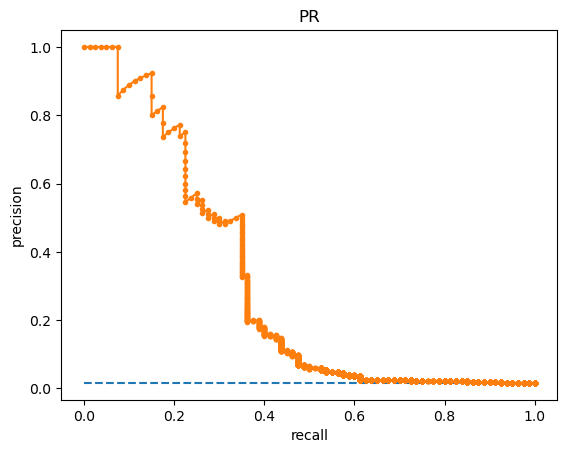

In [77]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [79]:
from numpy import argmax

In [81]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
pr_thresholds[ix]

0.16012618237188678

In [83]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.160126, F-Score=0.415


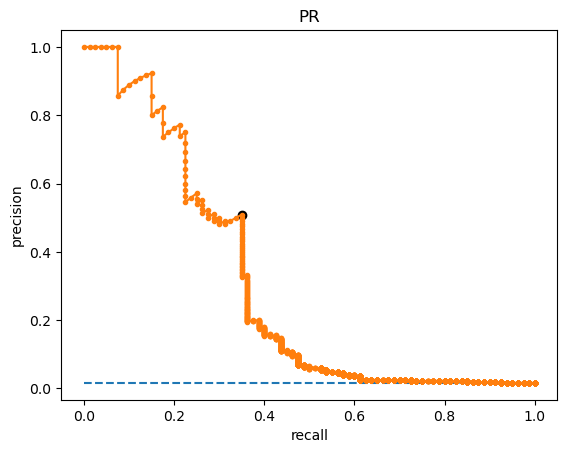

In [85]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [87]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4920
           1       0.50      0.34      0.40        80

    accuracy                           0.98      5000
   macro avg       0.74      0.67      0.70      5000
weighted avg       0.98      0.98      0.98      5000



А вот для сравнения, отчет о классификации для той же модели, но при использованиии порога по умолчанию:

In [92]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.74      0.17      0.28        80

    accuracy                           0.99      5000
   macro avg       0.86      0.59      0.64      5000
weighted avg       0.98      0.99      0.98      5000



### Домашняя работа

#### 1. Повторите анализ из лабораторной работы, но с двумерными датасетами. Изобразите графически, как изменение порога влияет на расположение границы принятия решений.

In [140]:
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [142]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [144]:
y_pred_proba = model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

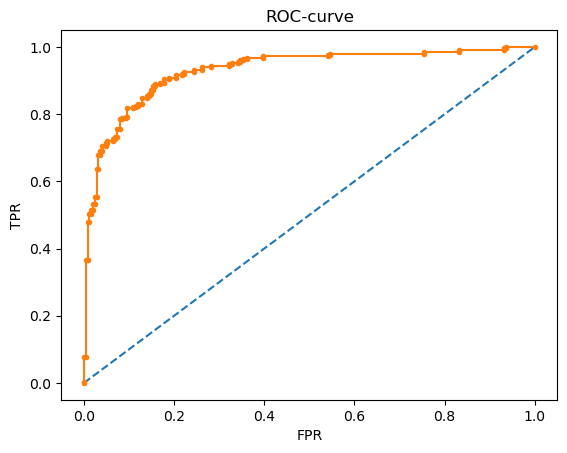

In [146]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [148]:
roc_auc_score(y_test, y_pred_proba[:, 1])

0.9301908830541288

In [150]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

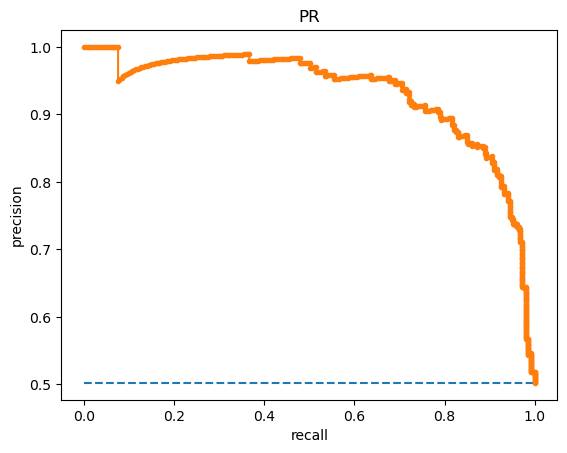

In [152]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [154]:
auc(recall, precision)

0.932321772410482

In [156]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       249
           1       0.87      0.84      0.85       251

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



In [158]:
model2 = KNeighborsClassifier(n_neighbors=250)
model2.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=250)

In [160]:
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

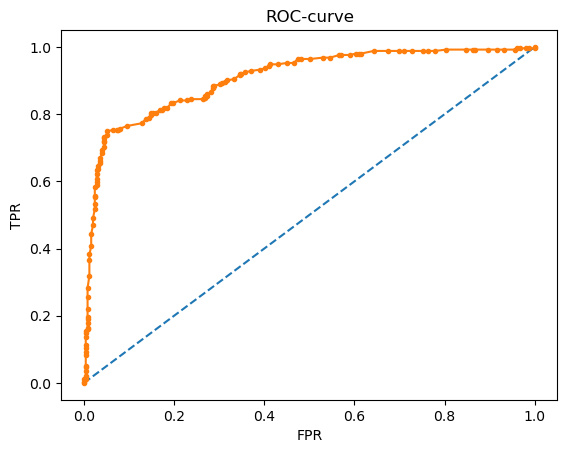

In [162]:
plt.title('ROC-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [164]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.9072625162002592

In [166]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2, n_clusters_per_class=1, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [168]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [172]:
y_pred_proba = model.predict_proba(X_test)
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)

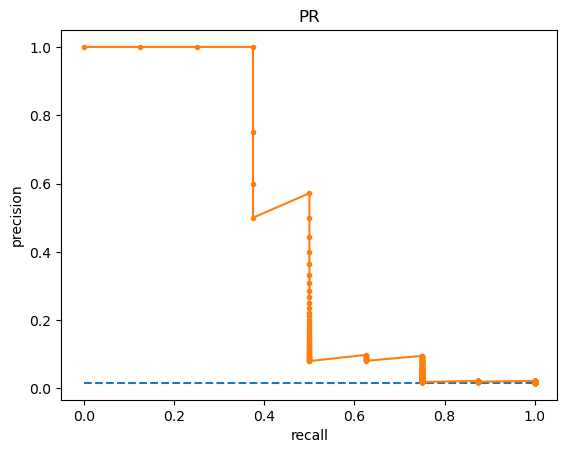

In [174]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [184]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)

In [186]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.297814, F-Score=0.545


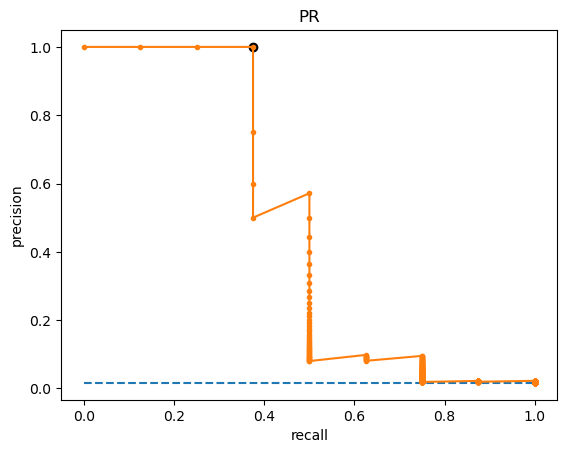

In [188]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [190]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       492
           1       1.00      0.25      0.40         8

    accuracy                           0.99       500
   macro avg       0.99      0.62      0.70       500
weighted avg       0.99      0.99      0.98       500



In [192]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       492
           1       1.00      0.25      0.40         8

    accuracy                           0.99       500
   macro avg       0.99      0.62      0.70       500
weighted avg       0.99      0.99      0.98       500



#### 2. Повторите анализ на реальном датасете для бинарной классификации. Проинтерпретируйте результат, сделайте вывод.

In [220]:
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris

data = load_breast_cancer()
#data = load_iris()

In [208]:
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [210]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [214]:
y_pred_proba = model.predict_proba(X_test)
y_test_binary = (y_test == 1).astype(int)
p, r, pr_thresholds = precision_recall_curve(y_test_binary, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)

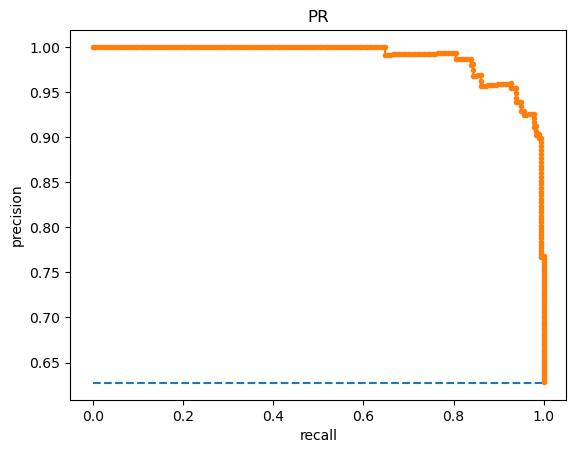

In [216]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [222]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       106
           1       0.93      0.95      0.94       179

    accuracy                           0.93       285
   macro avg       0.92      0.92      0.92       285
weighted avg       0.93      0.93      0.93       285



In [226]:
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train, y_train)

KNeighborsClassifier()

In [228]:
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test_binary, y_pred2_proba[:, 1])

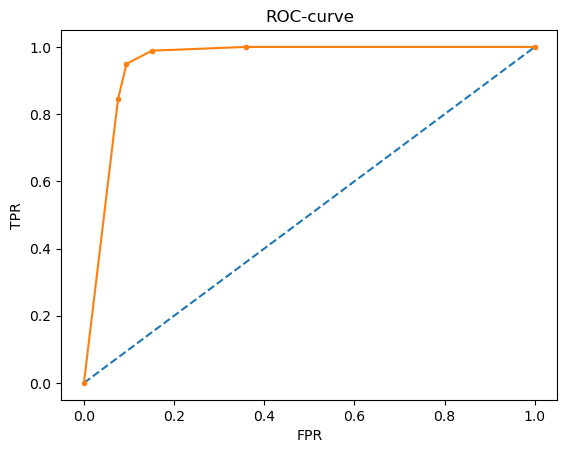

In [230]:
plt.title('ROC-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [232]:
roc_auc_score(y_test_binary, y_pred2_proba[:, 1])

0.9515125961842521

In [234]:
f1 = (2*p*r)/(p+r)
ix = argmax(f1)

In [236]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.318551, F-Score=0.951


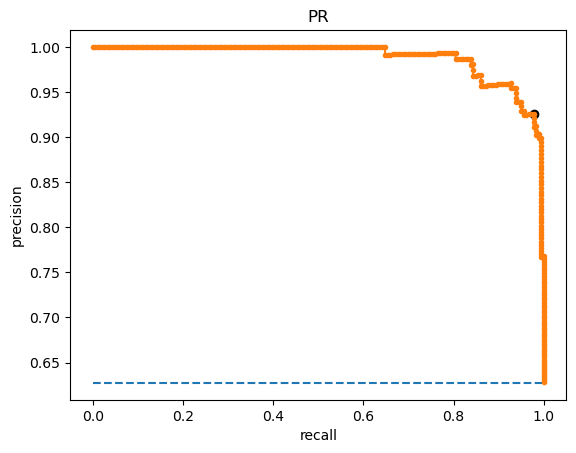

In [238]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [240]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       106
           1       0.93      0.97      0.95       179

    accuracy                           0.93       285
   macro avg       0.94      0.92      0.93       285
weighted avg       0.93      0.93      0.93       285



In [242]:
y_pred = model.predict(X_test)
print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       106
           1       0.93      0.95      0.94       179

    accuracy                           0.93       285
   macro avg       0.92      0.92      0.92       285
weighted avg       0.93      0.93      0.93       285



#### 3. В задании по оптимизации порога используйте ROC и среднее геометрическое между TPR и FPR как критерий оптимизации.

In [244]:
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train, y_train)

KNeighborsClassifier()

In [246]:
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test_binary, y_pred2_proba[:, 1])

In [248]:
f1 = (tpr + fpr)**0.5
ix = argmax(f1)

In [250]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.000000, F-Score=1.414


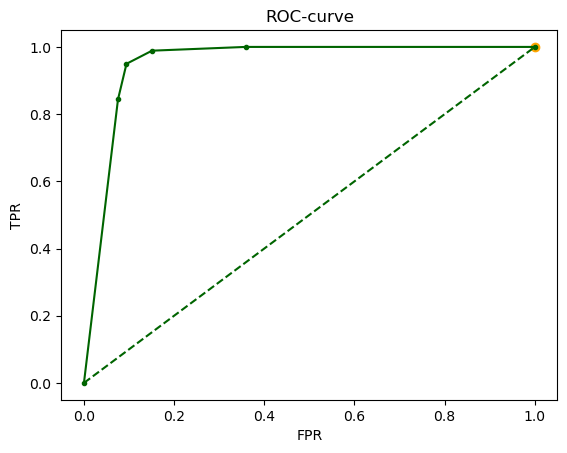

In [258]:
plt.title('ROC-curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot([0, 1], [0, 1], color='darkgreen', linestyle='--')
plt.plot(fpr, tpr, color='darkgreen', marker='.')
plt.scatter(tpr[ix], fpr[ix], marker='o', color='orange')
plt.show()

In [254]:
roc_auc_score(y_test_binary, y_pred2_proba[:, 1])

0.9515125961842521

#### 4. При оптимизации порога по PR-кривой используйте другую F-метрику - сначала с преимуществом precision, а затем - с превалированием recall. Изобразите получившиеся пороги на графике. Проанализируйте метрики получившихся моделей.

In [260]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2, n_clusters_per_class=1, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [262]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [264]:
y_pred_proba = model.predict_proba(X_test)
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)

In [266]:
fb1 = (1 + 0.5**2) * (p*r) / ((0.5**2 * p) + r) # precision, b < 1
fb2 = (1+2**2) *(p * r) / ((2**2 * p) + r) #recall, b > 1

In [268]:
ix1 = argmax(fb1)
ix2 = argmax(fb2)

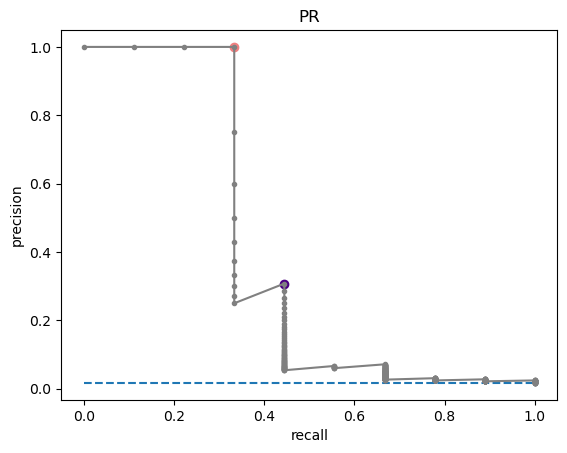

In [280]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, color='gray', marker='.')
plt.scatter(r[ix1], p[ix1], marker='o', color='lightcoral')
plt.scatter(r[ix2], p[ix2], marker='o', color='indigo')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

In [282]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix1]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       491
           1       1.00      0.22      0.36         9

    accuracy                           0.99       500
   macro avg       0.99      0.61      0.68       500
weighted avg       0.99      0.99      0.98       500



In [284]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix2]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       491
           1       0.25      0.33      0.29         9

    accuracy                           0.97       500
   macro avg       0.62      0.66      0.64       500
weighted avg       0.97      0.97      0.97       500



#### 5. Постройте классификационные кривые для задачи множественной классификации. Проинтерпретируйте результат.

In [357]:
from sklearn.preprocessing import label_binarize

In [361]:
X, y =  make_classification(n_samples = 1000, n_features=10, n_informative=5, n_classes=3, n_clusters_per_class=1, random_state=42)

In [363]:
y_bin = label_binarize(y, classes=[0,1,2])
n_classes = y_bin.shape[1]

In [365]:
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(X, y, y_bin, test_size=0.3, stratify=y)

In [367]:
y = label_binarize(y, classes=[0, 1, 2])
n_classes = y.shape[1]

In [369]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [371]:
y_pred_proba = model.predict_proba(X_test)

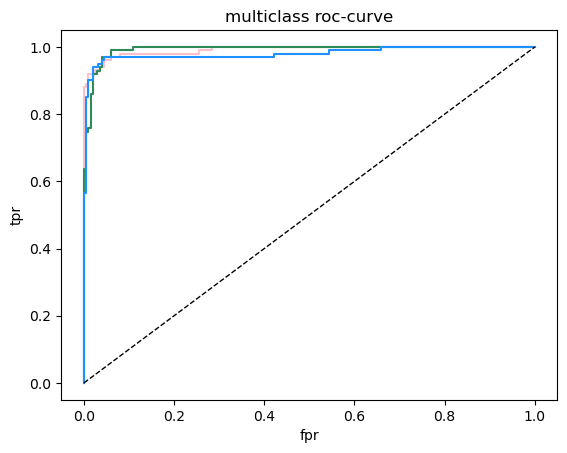

In [379]:
colors=['pink', 'seagreen', 'dodgerblue']

for i, color in enumerate(colors):
  fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, color = color, label=f'class{i}, auc={roc_auc}')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.title('multiclass roc-curve')
plt.ylabel('tpr')
plt.xlabel('fpr')
plt.show()

#### 6. Используйте для построения кривых библиотеку yellowbrick.

In [381]:
pip install yellowbrick

   ---------------------------------------- 0.0/282.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/282.6 kB ? eta -:--:--
   -- ------------------------------------ 20.5/282.6 kB 217.9 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/282.6 kB 326.8 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/282.6 kB 438.9 kB/s eta 0:00:01
   ------------------------------- -------- 225.3/282.6 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 282.6/282.6 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [413]:
from yellowbrick.classifier import ROCAUC, PrecisionRecallCurve
from yellowbrick.datasets import load_spam

In [415]:
X, y = load_spam()

In [417]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [419]:
model = LogisticRegression(multi_class="auto", solver="liblinear")

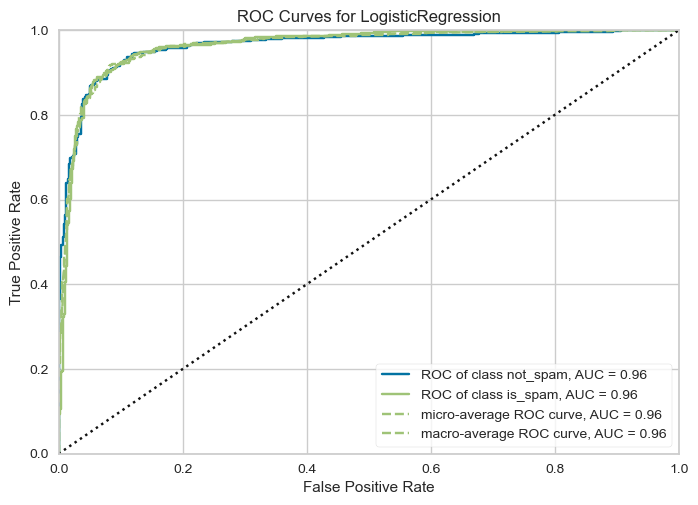

<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [421]:
visualizer = ROCAUC(model, classes=["not_spam", "is_spam"])

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

In [423]:
model = LogisticRegression(multi_class='ovr')

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


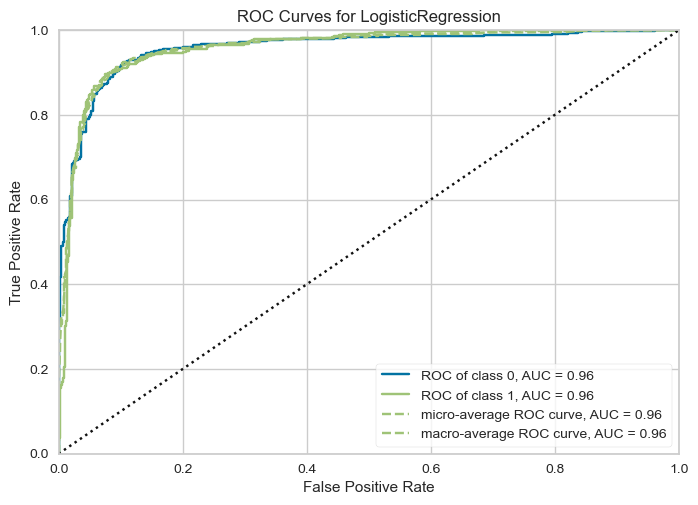

<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [425]:
visualizer = ROCAUC(model, classes=["0", "1", "2"])

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()